In [1]:
# Notebook 03: Exploratory Data Analysis (EDA)
# BEFORE: We have two cleaned datasets but no visual understanding of the data
# OPERATION: Load both cleaned files and set up visualization tools
# WHY: EDA is done BEFORE modeling because:
#      - You cannot build a good model without understanding patterns first
#      - It reveals seasonality, trends, outliers that affect model choice
#      - It helps decide which features matter most for forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH = os.path.join('..', 'data', 'processed')
EXPORTS_PATH   = os.path.join('..', 'exports')
os.makedirs(EXPORTS_PATH, exist_ok=True)

# Load both cleaned files
posoco = pd.read_csv(
    os.path.join(PROCESSED_PATH, 'posoco_cleaned.csv'),
    parse_dates=True, index_col='Date'
)

cea = pd.read_csv(
    os.path.join(PROCESSED_PATH, 'cea_cleaned.csv'),
    parse_dates=True, index_col='Date'
)

print("=== FILES LOADED ===")
print(f"POSOCO : {posoco.shape} | {posoco.index.min().date()} → {posoco.index.max().date()}")
print(f"CEA    : {cea.shape}  | {cea.index.min().date()} → {cea.index.max().date()}")
print(f"\nPOSOCO nulls : {posoco.isnull().sum().sum()}")
print(f"CEA nulls    : {cea.isnull().sum().sum()}")
print("\n Ready for EDA")

=== FILES LOADED ===
POSOCO : (4828, 138) | 2013-01-02 → 2026-03-22
CEA    : (2912, 16)  | 2018-04-01 → 2026-03-21

POSOCO nulls : 0
CEA nulls    : 0

 Ready for EDA


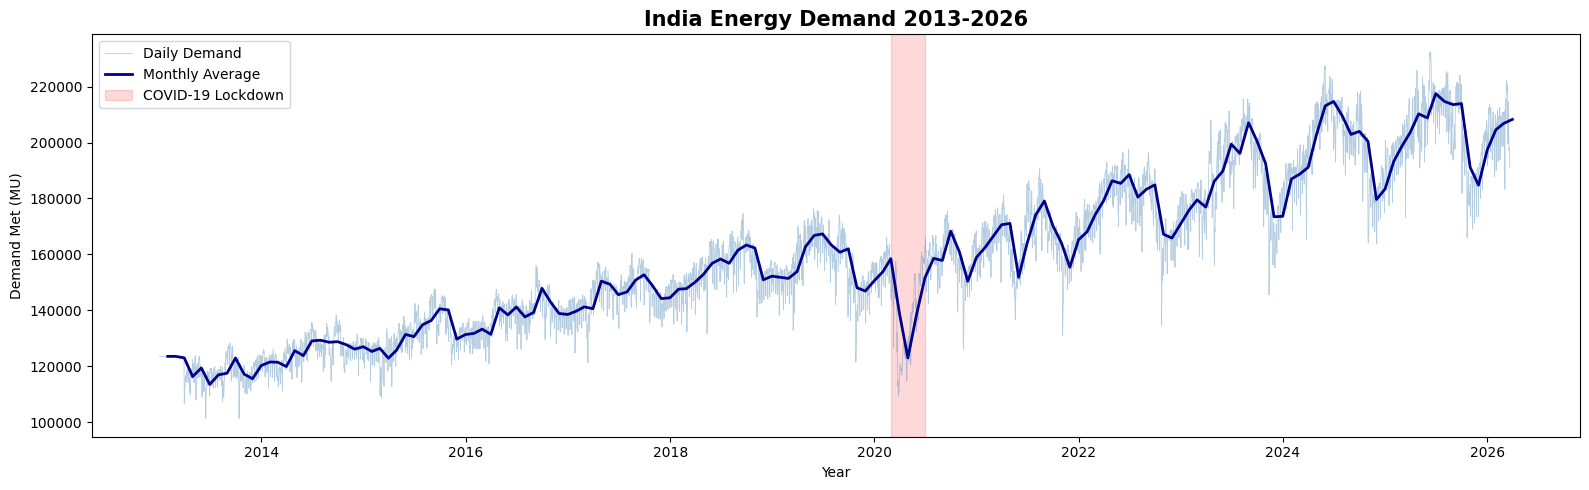

INSIGHT 1: Demand grew from ~1 lakh MU to ~2 lakh MU over 13 years
INSIGHT 2: COVID-19 caused visible dip in 2020
INSIGHT 3: Seasonal spikes every summer due to AC usage


In [2]:
# BEFORE: We have numbers but no visual understanding of demand over time
# OPERATION: Plot daily demand + monthly average
# WHY THIS CHART: This is the most fundamental chart in any energy project.
#                 It answers — is demand growing or shrinking?
#                 We plot BOTH daily (shows variability) and monthly average
#                 (shows trend) because daily alone is too noisy to read.
# WHY NOT bar chart: Line chart is standard for time series data.
#                    Bar chart would hide the continuous nature of demand.

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(posoco.index, posoco['India: DemandMet'],
        color='steelblue', linewidth=0.6, alpha=0.4, label='Daily Demand')

monthly_avg = posoco['India: DemandMet'].resample('ME').mean()
ax.plot(monthly_avg.index, monthly_avg.values,
        color='darkblue', linewidth=2, label='Monthly Average')

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'),
           color='red', alpha=0.15, label='COVID-19 Lockdown')

ax.set_title('India Energy Demand 2013-2026', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Demand Met (MU)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '01_demand_trend.png'), dpi=150)
plt.show()

print("INSIGHT 1: Demand grew from ~1 lakh MU to ~2 lakh MU over 13 years")
print("INSIGHT 2: COVID-19 caused visible dip in 2020")
print("INSIGHT 3: Seasonal spikes every summer due to AC usage")

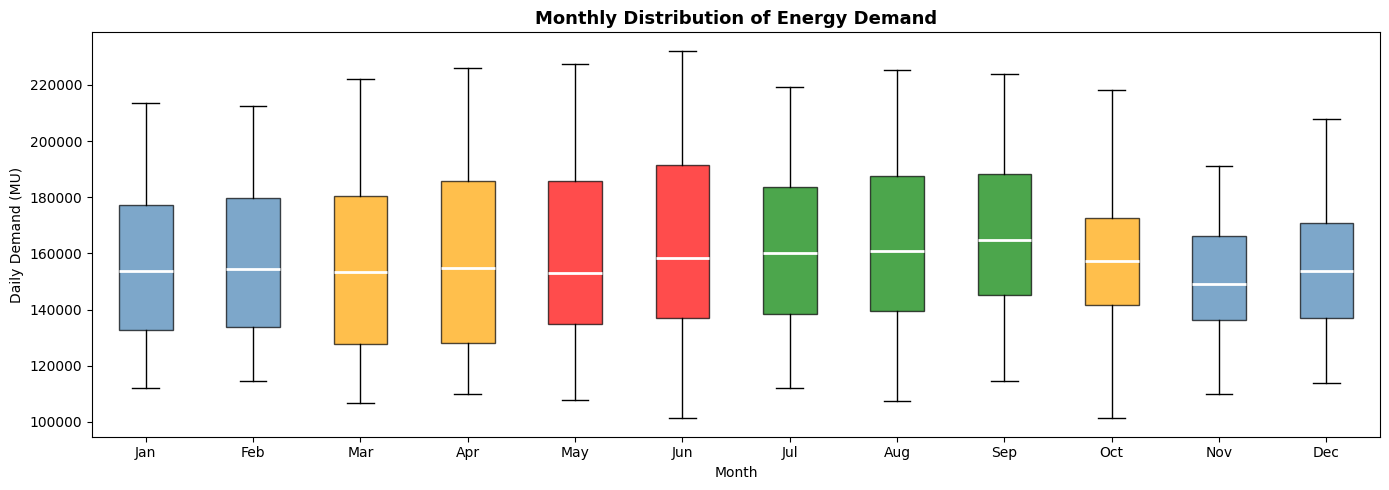

INSIGHT 1: May-June highest demand — summer AC load in India
INSIGHT 2: October-November lowest — mild weather, no heating or cooling
INSIGHT 3: This confirms Season and Month are important model features


In [3]:
# BEFORE: We can see trend but not which months are consistently high/low
# OPERATION: Boxplot of demand grouped by month
# WHY THIS CHART: Boxplot shows DISTRIBUTION per month, not just average.
#                 It reveals which months are always high, always low,
#                 and how much variation exists within each month.
#                 This directly proves that Month must be a model feature.
# WHY NOT line chart here: Line would only show average.
#                          Boxplot shows spread, outliers, median together.

fig, ax = plt.subplots(figsize=(14, 5))

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
data_by_month = [posoco[posoco.index.month == m]['India: DemandMet'].dropna().values
                 for m in range(1, 13)]

bp = ax.boxplot(data_by_month, labels=month_names, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

colors = ['steelblue','steelblue','orange','orange','red',
          'red','green','green','green','orange','steelblue','steelblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Monthly Distribution of Energy Demand', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Daily Demand (MU)')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '02_monthly_seasonality.png'), dpi=150)
plt.show()

print("INSIGHT 1: May-June highest demand — summer AC load in India")
print("INSIGHT 2: October-November lowest — mild weather, no heating or cooling")
print("INSIGHT 3: This confirms Season and Month are important model features")

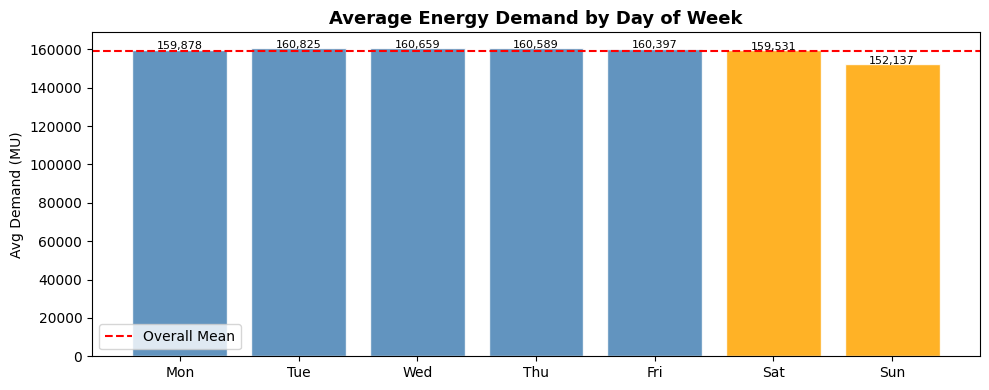

INSIGHT 1: Weekend demand is noticeably lower than weekdays
INSIGHT 2: This confirms Is_weekend as a useful model feature


In [4]:
# BEFORE: We don't know if day of week affects demand
# OPERATION: Bar chart of average demand by day of week
# WHY THIS CHART: Industrial and commercial consumption drops on weekends.
#                 If our model ignores this pattern it will always
#                 over-predict Saturdays and Sundays.
#                 This chart visually proves Is_weekend is a valid feature.
# WHY NOT pie chart: Pie charts don't show comparison well.
#                    Bar chart directly compares values across categories.

fig, ax = plt.subplots(figsize=(10, 4))

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
posoco_copy = posoco.copy()
posoco_copy['DOW'] = posoco_copy.index.dayofweek
dow_avg = posoco_copy.groupby('DOW')['India: DemandMet'].mean()

bar_colors = ['steelblue']*5 + ['orange','orange']
bars = ax.bar(day_names, dow_avg.values, color=bar_colors, alpha=0.85, edgecolor='white')

ax.axhline(dow_avg.mean(), color='red', linestyle='--', linewidth=1.5, label='Overall Mean')
ax.set_title('Average Energy Demand by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Demand (MU)')
ax.legend()

for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '03_weekday_weekend.png'), dpi=150)
plt.show()

print("INSIGHT 1: Weekend demand is noticeably lower than weekdays")
print("INSIGHT 2: This confirms Is_weekend as a useful model feature")

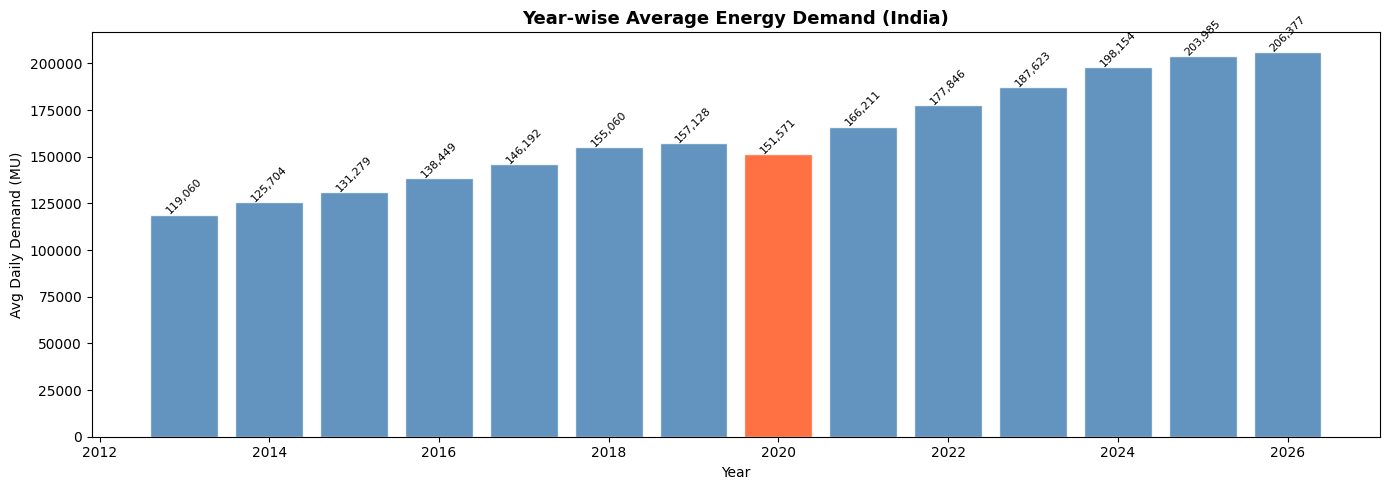

INSIGHT 1: Average year-on-year growth = 4.4%
INSIGHT 2: 2020 COVID impact clearly visible as red bar
INSIGHT 3: Growth resumed strongly post-COVID


In [5]:
# BEFORE: We see trend in line chart but not exact yearly numbers
# OPERATION: Bar chart of total demand per year
# WHY THIS CHART: Shows India's energy growth story in exact numbers.
#                 Each bar = one year's total demand.
#                 Growth rate can be calculated from this directly.
#                 Red bar highlights COVID impact year clearly.
# WHY NOT line chart: Bar chart makes year-by-year comparison easier
#                     because each year is a discrete unit.

fig, ax = plt.subplots(figsize=(14, 5))

yearly = posoco['India: DemandMet'].resample('YE').mean()

bar_colors = ['#FF5722' if y == 2020 else 'steelblue' for y in yearly.index.year]
bars = ax.bar(yearly.index.year, yearly.values, color=bar_colors, alpha=0.85, edgecolor='white')

ax.set_title('Year-wise Average Energy Demand (India)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Daily Demand (MU)')

for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,.0f}', ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '04_yearly_demand.png'), dpi=150)
plt.show()

yoy = yearly.pct_change().dropna() * 100
print(f"INSIGHT 1: Average year-on-year growth = {yoy.mean():.1f}%")
print(f"INSIGHT 2: 2020 COVID impact clearly visible as red bar")
print(f"INSIGHT 3: Growth resumed strongly post-COVID")

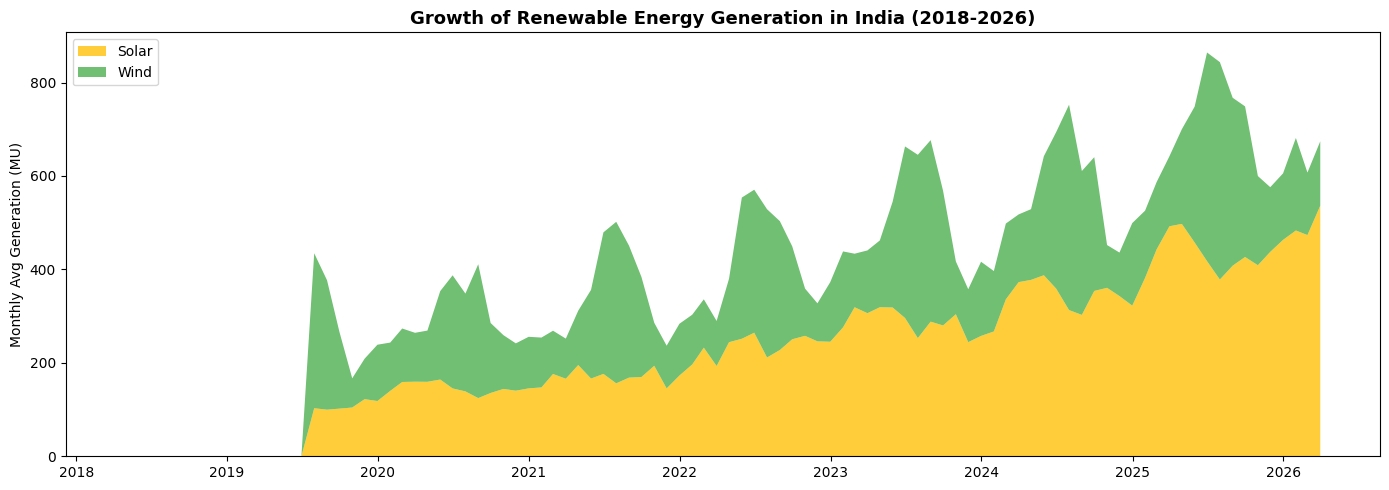

INSIGHT 1: Solar has grown dramatically since 2018
INSIGHT 2: Wind growth is more gradual but consistent
INSIGHT 3: Combined renewables now significant part of energy mix


In [6]:
# BEFORE: We know solar/wind exist in data but don't know their growth story
# OPERATION: Stacked area chart of Solar + Wind generation over time
# WHY THIS CHART: India's renewable push is a key policy story since 2015.
#                 Stacked area shows both total renewables AND
#                 individual contribution of solar vs wind simultaneously.
#                 This is impossible to show clearly with a line chart.
# WHY THIS MATTERS FOR FORECASTING: More renewables = more supply variability
#                 = demand forecasting becomes even more critical

fig, ax = plt.subplots(figsize=(14, 5))

cea_monthly = cea.resample('ME').mean()

ax.stackplot(cea_monthly.index,
             cea_monthly['Solar'].fillna(0),
             cea_monthly['Wind'].fillna(0),
             labels=['Solar', 'Wind'],
             colors=['#FFC107', '#4CAF50'], alpha=0.8)

ax.set_title('Growth of Renewable Energy Generation in India (2018-2026)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Avg Generation (MU)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '05_renewable_growth.png'), dpi=150)
plt.show()

print("INSIGHT 1: Solar has grown dramatically since 2018")
print("INSIGHT 2: Wind growth is more gradual but consistent")
print("INSIGHT 3: Combined renewables now significant part of energy mix")

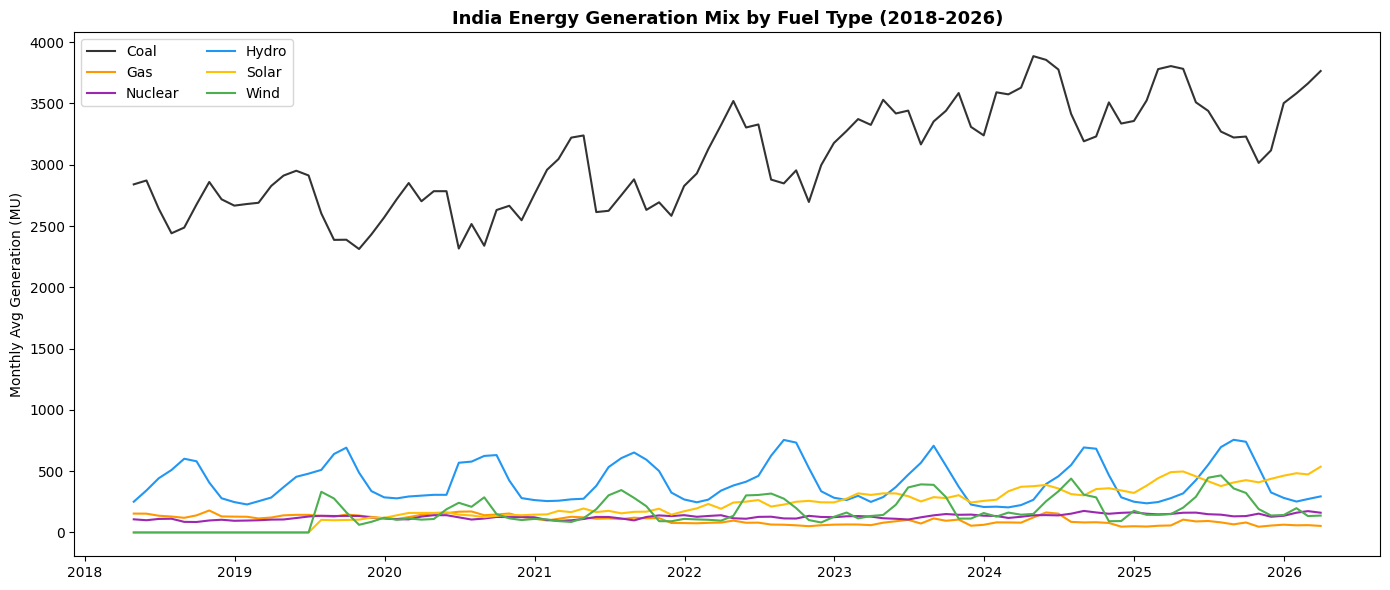

INSIGHT 1: Coal remains dominant but renewables are rising
INSIGHT 2: Nuclear is stable — baseload generation
INSIGHT 3: Hydro varies seasonally with monsoon


In [7]:
# BEFORE: We don't know how India's fuel mix has changed over time
# OPERATION: Line chart of Coal, Gas, Nuclear, Hydro, Solar, Wind over time
# WHY THIS CHART: Shows energy transition story — coal dominance reducing,
#                 renewables increasing. This context is important for
#                 understanding future demand patterns.
# WHY NOT pie chart: Pie chart shows one point in time only.
#                    Line chart shows how the mix CHANGED over years.

fig, ax = plt.subplots(figsize=(14, 6))

cea_monthly = cea.resample('ME').mean()

fuel_cols   = ['Coal', 'Gas', 'Nuclear', 'Hydro', 'Solar', 'Wind']
fuel_colors = ['#333333', '#FF9800', '#9C27B0', '#2196F3', '#FFC107', '#4CAF50']

for col, color in zip(fuel_cols, fuel_colors):
    if col in cea_monthly.columns:
        ax.plot(cea_monthly.index, cea_monthly[col],
                linewidth=1.5, label=col, color=color)

ax.set_title('India Energy Generation Mix by Fuel Type (2018-2026)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Avg Generation (MU)')
ax.legend(loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '06_generation_mix.png'), dpi=150)
plt.show()

print("INSIGHT 1: Coal remains dominant but renewables are rising")
print("INSIGHT 2: Nuclear is stable — baseload generation")
print("INSIGHT 3: Hydro varies seasonally with monsoon")

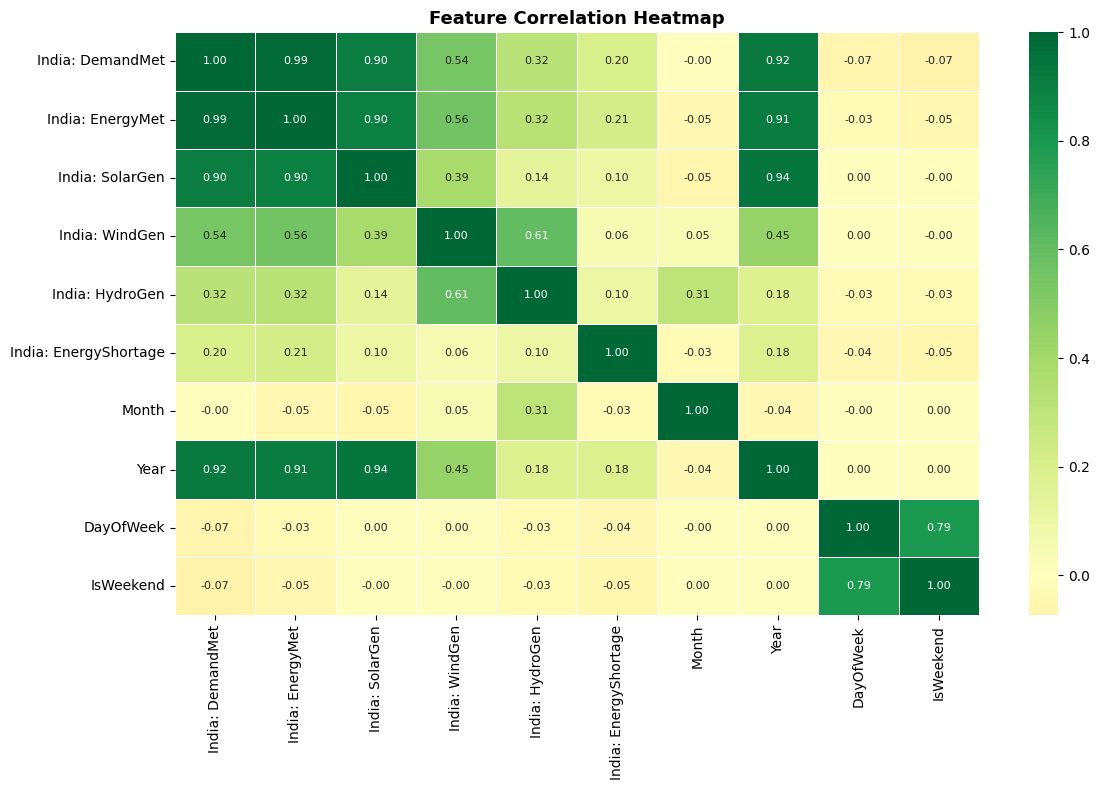

INSIGHT 1: EnergyMet highly correlated with DemandMet — expected
INSIGHT 2: Year positively correlated — confirms growth trend
INSIGHT 3: IsWeekend negatively correlated — confirms weekend dip


In [8]:
# BEFORE: We don't know which features are related to demand
# OPERATION: Correlation heatmap of key columns
# WHY THIS CHART: Correlation tells us which features move together with demand.
#                 High correlation = good predictor for our model.
#                 Also reveals multicollinearity between features
#                 which affects model selection.
# WHY NOT scatter plots: Heatmap shows ALL correlations at once.
#                        Scatter plots would need one per pair = too many charts.

key_cols = ['India: DemandMet', 'India: EnergyMet', 'India: SolarGen',
            'India: WindGen', 'India: HydroGen', 'India: EnergyShortage']

posoco_copy = posoco.copy()
posoco_copy['Month']      = posoco_copy.index.month
posoco_copy['Year']       = posoco_copy.index.year
posoco_copy['DayOfWeek']  = posoco_copy.index.dayofweek
posoco_copy['IsWeekend']  = (posoco_copy['DayOfWeek'] >= 5).astype(int)

corr_cols = key_cols + ['Month', 'Year', 'DayOfWeek', 'IsWeekend']
corr_cols = [c for c in corr_cols if c in posoco_copy.columns]

corr = posoco_copy[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '07_correlation_heatmap.png'), dpi=150)
plt.show()

print("INSIGHT 1: EnergyMet highly correlated with DemandMet — expected")
print("INSIGHT 2: Year positively correlated — confirms growth trend")
print("INSIGHT 3: IsWeekend negatively correlated — confirms weekend dip")

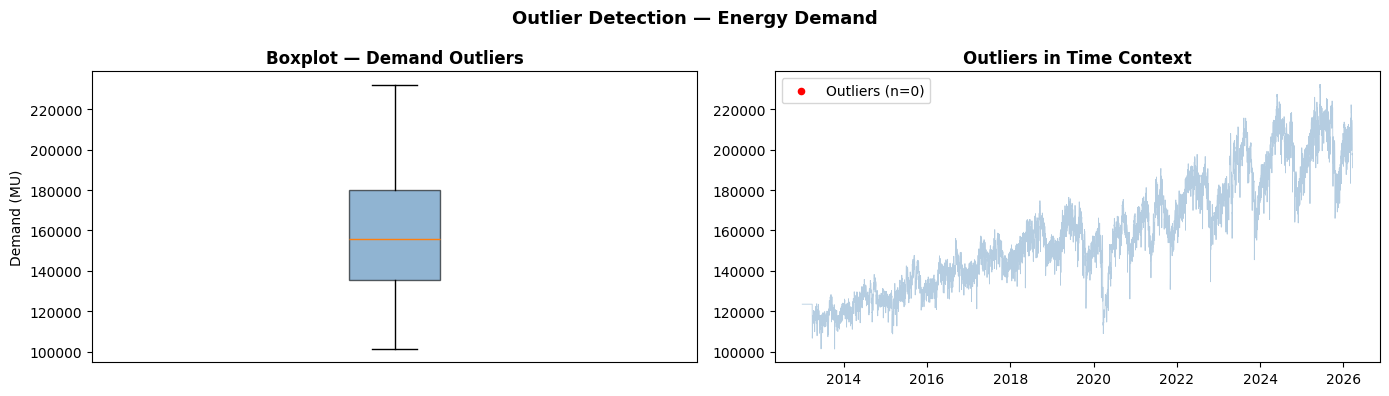

INSIGHT 1: 0 outliers found using z-score > 3
INSIGHT 2: Outliers are real events — COVID dip, summer peaks
INSIGHT 3: Decision — KEEP outliers, they represent real scenarios


In [9]:
# BEFORE: We don't know if extreme values exist that could break our model
# OPERATION: Boxplot + time series with outliers highlighted
# WHY THIS CHART: Outliers distort model training if not handled.
#                 We need to decide — are they errors or real events?
#                 Plotting them in time context reveals if they are
#                 COVID dip, extreme weather, or data errors.
# WHY NOT just remove them: Real events like COVID must be KEPT
#                           because our model must handle such scenarios.

from scipy.stats import zscore

demand = posoco['India: DemandMet'].dropna()
z_scores = zscore(demand)
outliers = demand[abs(z_scores) > 3]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(demand, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Boxplot — Demand Outliers', fontweight='bold')
axes[0].set_ylabel('Demand (MU)')
axes[0].set_xticks([])

axes[1].plot(posoco.index, posoco['India: DemandMet'],
             alpha=0.4, linewidth=0.6, color='steelblue')
axes[1].scatter(outliers.index, outliers.values,
                color='red', s=20, zorder=5, label=f'Outliers (n={len(outliers)})')
axes[1].set_title('Outliers in Time Context', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Outlier Detection — Energy Demand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '08_outliers.png'), dpi=150)
plt.show()

print(f"INSIGHT 1: {len(outliers)} outliers found using z-score > 3")
print("INSIGHT 2: Outliers are real events — COVID dip, summer peaks")
print("INSIGHT 3: Decision — KEEP outliers, they represent real scenarios")

In [12]:
# OPERATION: Export clean summary CSVs for Power BI dashboard
# WHY: Power BI needs CSV files to build visuals.
#      We export pre-aggregated data so Power BI loads fast.
#      Raw 4828-row files work but aggregated ones are cleaner for dashboards.

# Export 1: Yearly demand
yearly_export = posoco['India: DemandMet'].resample('YE').agg(['mean','max','min']).reset_index()
yearly_export.columns = ['Date','Avg_Demand','Max_Demand','Min_Demand']
yearly_export['Year'] = yearly_export['Date'].dt.year
yearly_export.to_csv(os.path.join(EXPORTS_PATH, 'powerbi_yearly.csv'), index=False)

# Export 2: Monthly demand
posoco_copy = posoco.copy()
posoco_copy['Year']  = posoco_copy.index.year
posoco_copy['Month'] = posoco_copy.index.month
monthly_export = posoco_copy.groupby(['Year','Month'])['India: DemandMet'].mean().reset_index()
monthly_export.to_csv(os.path.join(EXPORTS_PATH, 'powerbi_monthly.csv'), index=False)

# Export 3: Regional demand
region_cols = ['India: DemandMet','NR: DemandMet','WR: DemandMet',
               'SR: DemandMet','ER: DemandMet','NER: DemandMet']
region_cols = [c for c in region_cols if c in posoco.columns]
regional = posoco[region_cols].resample('YE').mean().reset_index()
regional.to_csv(os.path.join(EXPORTS_PATH, 'powerbi_regional.csv'), index=False)

# Export 4: Generation mix
gen_cols = ['Coal','Gas','Nuclear','Hydro','Solar','Wind']
gen_cols = [c for c in gen_cols if c in cea.columns]
gen_export = cea[gen_cols].resample('ME').mean().reset_index()
gen_export.to_csv(os.path.join(EXPORTS_PATH, 'powerbi_generation_mix.csv'), index=False)

print("=== POWER BI EXPORTS SAVED ===")
print(f"powerbi_yearly.csv          ")
print(f"powerbi_monthly.csv         ")
print(f"powerbi_regional.csv        ")
print(f"powerbi_generation_mix.csv  ")
print(f"\nAll files in: {EXPORTS_PATH}")


=== POWER BI EXPORTS SAVED ===
powerbi_yearly.csv          
powerbi_monthly.csv         
powerbi_regional.csv        
powerbi_generation_mix.csv  

All files in: ..\exports
